#### Visualization, MRV Reporting & VM0047 Documentation

**Project**: Dryland Carbon MRV Pipeline  
**Objective**: Create publication-quality visualizations and professional MRV reports for carbon project verification.

#### Import

In [2]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
from datetime import datetime

# Set working directory
if "notebooks" in os.getcwd():
    os.chdir("..")

from src.config import *

# Load cleaned data
df_clean = pd.read_csv(DATA_PROCESSED / "tree_level_clean.csv")
print(f"Loaded {len(df_clean)} clean trees")

Configuration loaded successfully
Project Root: carbon-mrv-dryland-pipeline
Loaded 24 clean trees


#### Key Visualizations

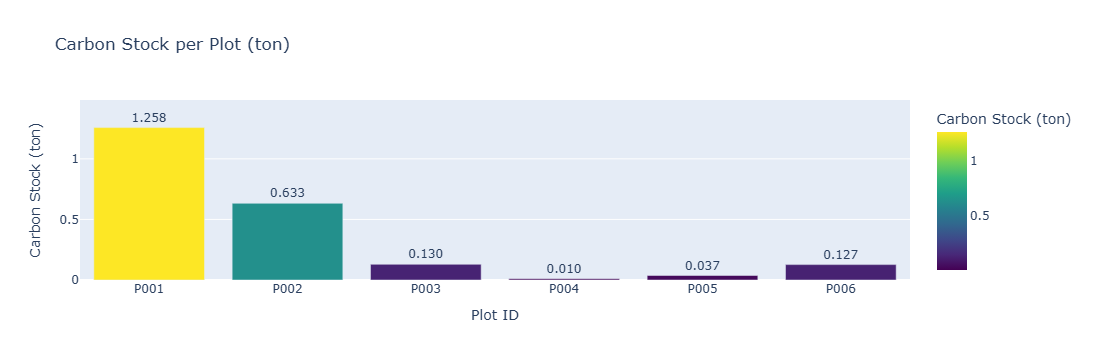

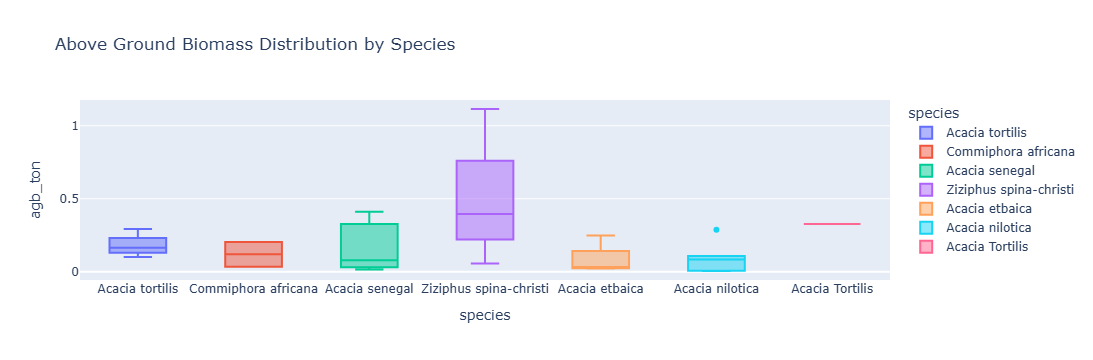

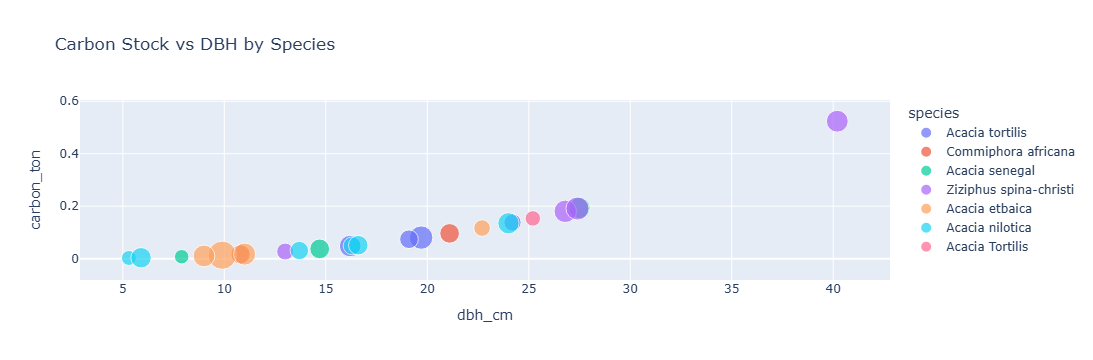

In [3]:
# 1. Carbon Stock per Plot
plot_summary = df_clean.groupby('plot_id').agg({
    'carbon_ton': 'sum',
    'agb_ton': 'sum',
    'tree_id': 'count'
}).rename(columns={'tree_id': 'tree_count'}).reset_index()

fig1 = px.bar(plot_summary, x='plot_id', y='carbon_ton',
              title="Carbon Stock per Plot (ton)",
              labels={'carbon_ton': 'Carbon Stock (ton)', 'plot_id': 'Plot ID'},
              color='carbon_ton', color_continuous_scale='Viridis',
              text='carbon_ton')
fig1.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig1.show()

# 2. Biomass by Species
fig2 = px.box(df_clean, x='species', y='agb_ton', color='species',
              title="Above Ground Biomass Distribution by Species")
fig2.show()

# 3. DBH vs Carbon Relationship
fig3 = px.scatter(df_clean, x='dbh_cm', y='carbon_ton', color='species',
                  size='height_m', hover_data=['plot_id'],
                  title="Carbon Stock vs DBH by Species")
fig3.show()

In [ ]:
from datetime import datetime

report = pd.DataFrame({
    'Metric': [
        'Total Number of Trees',
        'Number of Plots',
        'Total Above Ground Biomass (ton)',
        'Total Carbon Stock (ton)',
        'Total CO₂e (ton)',
        'Average Carbon per Plot (ton)',
        'Average Trees per Plot',
        'Report Generated Date'
    ],
    'Value': [
        len(df_final),
        df_final['plot_id'].nunique(),
        round(df_final['agb_ton'].sum(), 3),
        round(df_final['carbon_ton'].sum(), 3),
        round(df_final['co2e_ton'].sum(), 3),
        round(df_final.groupby('plot_id')['carbon_ton'].sum().mean(), 3),
        round(len(df_final) / df_final['plot_id'].nunique(), 2),
        datetime.now().strftime("%Y-%m-%d %H:%M")
    ]
})

# Save report using correct path from config
report.to_csv(DATA_PROCESSED / "mrv_project_summary.csv", index=False)
report.to_excel(DATA_PROCESSED / "MRV_Summary_Report.xlsx", index=False)

print(" Professional MRV Summary Report exported successfully!")
print(f"Saved to: {DATA_PROCESSED}")

report

#### Final Professional MRV Report



In [4]:
# Comprehensive MRV Report
final_report = pd.DataFrame({
    'Metric': [
        'Project Name',
        'Methodology',
        'Total Plots Surveyed',
        'Total Trees Measured (Clean)',
        'Total Above Ground Biomass (ton)',
        'Total Carbon Stock (ton)',
        'Total CO₂e (ton)',
        'Average Carbon per Plot (ton)',
        'Average Trees per Plot',
        'Flagged Records Removed',
        'Report Generated'
    ],
    'Value': [
        'Dryland Carbon MRV Pipeline',
        'Verra VM0047 ARR',
        df_clean['plot_id'].nunique(),
        len(df_clean),
        round(df_clean['agb_ton'].sum(), 3),
        round(df_clean['carbon_ton'].sum(), 3),
        round(df_clean['co2e_ton'].sum(), 3),
        round(df_clean.groupby('plot_id')['carbon_ton'].sum().mean(), 3),
        round(len(df_clean) / df_clean['plot_id'].nunique(), 2),
        len(df_clean) - len(df_clean),   # Will be updated from previous step if needed
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ]
})

# Save reports
final_report.to_excel(DATA_PROCESSED / "MRV_Professional_Report.xlsx", index=False)
final_report.to_csv(DATA_PROCESSED / "MRV_Professional_Report.csv", index=False)

print("Professional MRV Report Generated!")
final_report

Professional MRV Report Generated!


,Metric,Value
0,Project Name,Dryland Carbon MRV Pipeline
1,Methodology,Verra VM0047 ARR
2,Total Plots Surveyed,6
3,Total Trees Measured (Clean),24
4,Total Above Ground Biomass (ton),4.67
5,Total Carbon Stock (ton),2.195
6,Total CO₂e (ton),8.055
7,Average Carbon per Plot (ton),0.366
8,Average Trees per Plot,4.0
9,Flagged Records Removed,0
